## 부산항 컨테이너 성장에서 환적의 기여 구조 파악
초기 기간 환적기여율: 52.62%(2013-2017)
최근 기간 환적기여율: 83.82%(2021-2025)
차이: 31.21%p
최근 기간에 전체 물동량 증가에 대한 환적의 기여가 초기 기간보다 커졌다는 방향으로 해석할 수 있습니다.

In [7]:
import pandas as pd
import numpy as np

In [6]:
import matplotlib.pyplot as plt

In [8]:
CSV_PATH = './data/부산광역시_부산항 물동량 현황_20251231.csv'
df = pd.read_csv(CSV_PATH, encoding='cp949')

In [ ]:
df.head()

,연도,컨물동량,증감율,수출입소계,수입,수출,환적소계,환적점유율,환적증감율
0,2013,17686,3.75,8934,4424,4509,8748,49.47,7.38
1,2014,18683,5.64,9254,4596,4658,9429,50.47,7.78
2,2015,19469,4.20,9364,4714,4650,10105,51.91,7.17
3,2016,19456,-0.06,9620,4801,4819,9836,50.55,-2.67
4,2017,20493,5.33,10186,5042,5144,10225,49.90,3.96


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연도      13 non-null     int64  
 1    컨물동량   13 non-null     int64  
 2   증감율     13 non-null     float64
 3   수출입소계   13 non-null     int64  
 4   수입      13 non-null     int64  
 5   수출      13 non-null     int64  
 6   환적소계    13 non-null     int64  
 7   환적점유율   13 non-null     float64
 8   환적증감율   13 non-null     float64
dtypes: float64(3), int64(6)
memory usage: 1.0 KB


In [ ]:
df.dtypes

연도         int64
 컨물동량      int64
증감율      float64
수출입소계      int64
수입         int64
수출         int64
환적소계       int64
환적점유율    float64
환적증감율    float64
dtype: object

In [11]:
df['전체증감량'] = df['컨물동량'].diff()
df['환적증감량'] = df['환적소계'].diff()

df['환적기여율'] = (
    df['환적증감량'] / df['전체증감량']
) * 100

df[['연도', '전체증감량', '환적증감량', '환적기여율']]



,연도,전체증감량,환적증감량,환적기여율
0,2013,NaN,NaN,NaN
1,2014,997.0,681.0,68.304915
2,2015,786.0,676.0,86.005089
3,2016,-13.0,-269.0,2069.230769
4,2017,1037.0,389.0,37.512054
5,2018,1170.0,1204.0,102.905983
6,2019,329.0,209.0,63.525836
7,2020,-168.0,382.0,-227.380952
8,2021,882.0,253.0,28.684807
9,2022,-628.0,-507.0,80.732484


In [ ]:
df['전체증감량'] = df['컨물동량'].diff()
df['환적증감량'] = df['환적소계'].diff()
df['수출입증감량'] = df['수출입소계'].diff()

df['환적기여율'] = (
    df['환적증감량'] / df['전체증감량'] * 100
)

df[['연도', '전체증감량', '환적증감량',
    '수출입증감량', '환적기여율']]

def classify(row):
    total = row['전체증감량']
    trans = row['환적증감량']

    if total > 0 and trans > 0:
        if trans > total:
            return '환적 주도 증가'
        else:
            return '환적 증가 기여'

    elif total < 0 and trans > 0:
        return '환적이 감소 완화'

    elif total > 0 and trans < 0:
        return '환적이 증가 억제'

    elif total < 0 and trans < 0:
        return '환적이 감소에 기여'

    else:
        return '변화 없음'

df['환적역할'] = df.apply(classify, axis=1)

df[['연도', '전체증감량', '환적증감량',
    '환적기여율', '환적역할']]

,연도,전체증감량,환적증감량,환적기여율,환적역할
0,2013,NaN,NaN,NaN,변화 없음
1,2014,997.0,681.0,68.304915,환적 증가 기여
2,2015,786.0,676.0,86.005089,환적 증가 기여
3,2016,-13.0,-269.0,2069.230769,환적이 감소에 기여
4,2017,1037.0,389.0,37.512054,환적 증가 기여
5,2018,1170.0,1204.0,102.905983,환적 주도 증가
6,2019,329.0,209.0,63.525836,환적 증가 기여
7,2020,-168.0,382.0,-227.380952,환적이 감소 완화
8,2021,882.0,253.0,28.684807,환적 증가 기여
9,2022,-628.0,-507.0,80.732484,환적이 감소에 기여


과거 평균: 52.44083333333333
최근 평균: 56.7


c:\work\report2\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\work\report2\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\work\report2\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\work\report2\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\work\report2\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\work\report2\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE G

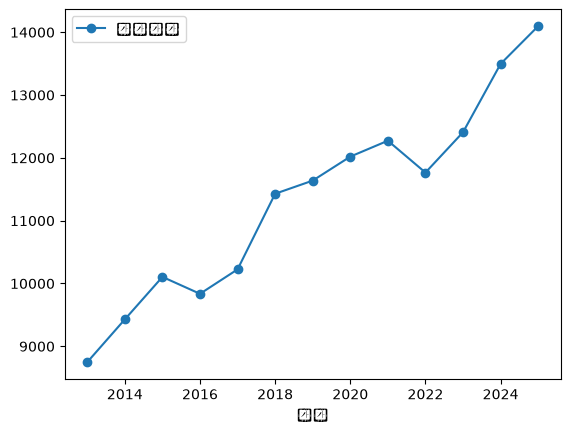

In [ ]:
df[['연도', '컨물동량', '환적소계', '환적점유율', '환적기여율']]
import matplotlib.pyplot as plt
df.plot(
    x='연도',
    y='환적소계',
    marker='o'
)

In [15]:
df[['연도', '환적기여율']]

,연도,환적기여율
0,2013,NaN
1,2014,68.304915
2,2015,86.005089
3,2016,2069.230769
4,2017,37.512054
5,2018,102.905983
6,2019,63.525836
7,2020,-227.380952
8,2021,28.684807
9,2022,80.732484


In [17]:
초기 = df[df['연도'].between(2013, 2017)]['환적점유율'].mean()
최근 = df[df['연도'].between(2021, 2025)]['환적점유율'].mean()

print(f"초기 5년 평균: {초기:.2f}%")
print(f"최근 5년 평균: {최근:.2f}%")
print(f"차이: {최근-초기:.2f}%p")

초기 5년 평균: 50.46%
최근 5년 평균: 54.59%
차이: 4.13%p


In [18]:
시작 = df.loc[df['연도'] == 2013, '환적소계'].iloc[0]
마지막 = df.loc[df['연도'] == 2025, '환적소계'].iloc[0]

증가율 = (마지막 - 시작) / 시작 * 100

print(f"환적 물동량 증가율: {증가율:.2f}%")

환적 물동량 증가율: 61.15%


In [21]:
초기전체증가 = (
    df.loc[df['연도'] == 2017, '컨물동량'].iloc[0]
    - df.loc[df['연도'] == 2013, '컨물동량'].iloc[0]
)

초기환적증가 = (
    df.loc[df['연도'] == 2017, '환적소계'].iloc[0]
    - df.loc[df['연도'] == 2013, '환적소계'].iloc[0]
)

초기기여율 = 초기환적증가 / 초기전체증가 * 100

최근전체증가 = (
    df.loc[df['연도'] == 2025, '컨물동량'].iloc[0]
    - df.loc[df['연도'] == 2021, '컨물동량'].iloc[0]
)

최근환적증가 = (
    df.loc[df['연도'] == 2025, '환적소계'].iloc[0]
    - df.loc[df['연도'] == 2021, '환적소계'].iloc[0]
)

최근기여율 = 최근환적증가 / 최근전체증가 * 100

print(f"초기 기간 환적기여율: {초기기여율:.2f}%")
print(f"최근 기간 환적기여율: {최근기여율:.2f}%")
print(f"차이: {최근기여율 - 초기기여율:.2f}%p")

초기 기간 환적기여율: 52.62%
최근 기간 환적기여율: 83.82%
차이: 31.21%p


In [10]:
print(df.columns)
df.columns = df.columns.str.strip()
print(df.columns)

Index(['연도', ' 컨물동량', '증감율', '수출입소계', '수입', '수출', '환적소계', '환적점유율', '환적증감율'], dtype='str')
Index(['연도', '컨물동량', '증감율', '수출입소계', '수입', '수출', '환적소계', '환적점유율', '환적증감율'], dtype='str')


In [ ]:
df['전체증감량'] = df['컨물동량'].diff()
df['환적증감량'] = df['환적소계'].diff()
AL = df['전체증감량'].sum()
TR = df['환적증감량'].sum()

PR = (
    TR / AL
) * 100

PR

np.float64(74.33296275708727)

In [ ]:
contribution = df[["연도", "컨물동량", "수출입소계", "환적소계"]].copy()
contribution["총증분"] = contribution["컨물동량"].diff()
contribution["수출입증분"] = contribution["수출입소계"].diff()
contribution["환적증분"] = contribution["환적소계"].diff()
contribution["환적기여율"] = contribution["환적증분"] / contribution["총증분"]
contribution

,연도,컨물동량,수출입소계,환적소계,총증분,수출입증분,환적증분,환적기여율
0,2013,17686,8934,8748,NaN,NaN,NaN,NaN
1,2014,18683,9254,9429,997.0,320.0,681.0,0.683049
2,2015,19469,9364,10105,786.0,110.0,676.0,0.860051
3,2016,19456,9620,9836,-13.0,256.0,-269.0,20.692308
4,2017,20493,10186,10225,1037.0,566.0,389.0,0.375121
5,2018,21663,10233,11429,1170.0,47.0,1204.0,1.029060
6,2019,21992,10354,11638,329.0,121.0,209.0,0.635258
7,2020,21824,9804,12020,-168.0,-550.0,382.0,-2.273810
8,2021,22706,10433,12273,882.0,629.0,253.0,0.286848
9,2022,22078,10311,11766,-628.0,-122.0,-507.0,0.807325
